In [2]:
import numpy as np
import matplotlib.pyplot as plt
from math import factorial
import bpmeth


Scalar potential phi(x,y): s*x**2 + x**4/4 + 5*x**3/6 + y**4/4 - y**3*(12*x*(2*s**2 - 1)*exp(-s**2) + 24*x + 18)/36 - y**2*(48*s + 72*x**2 + 120*x)/48 + y*(4*x**3 + 9*x**2 + 6*x*exp(-s**2) + 6)/6


/home/fmarcoli/bpmeth/src/bpmeth/generate_expansion.py:94: UserWarning: More terms are needed in the expansion for aperture 0.05m, the laplacian is -0.0000123442050462633
  warnings.warn(f"More terms are needed in the expansion for aperture {apperture}m, the laplacian is {laplval}")


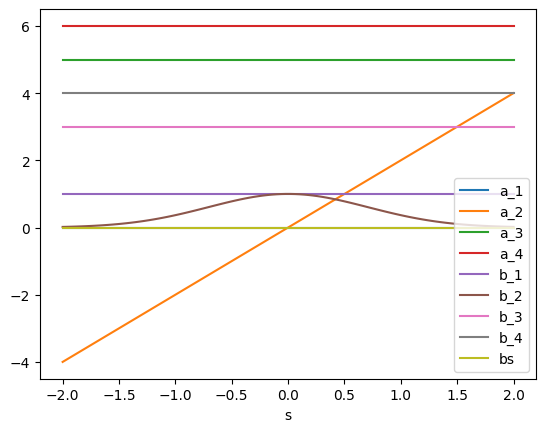

In [3]:
#start from multipole coeefficients a_n and b_n
a_coeffs = [0, "2*s", 5, 6]
b_coeffs = [1, "exp(-s**2)", 3, 4]
#get scalar potential
expansion=bpmeth.FieldExpansion(a=a_coeffs, b=b_coeffs)
expansion.plot_components()
plt.xlabel('s')
phi=expansion.get_phi()
print("Scalar potential phi(x,y):", phi)

/home/fmarcoli/bpmeth/src/bpmeth/fieldmaps.py:128: UserWarning: Failed to use notebook backend: 

No module named 'trame'

Falling back to a static output.
  self.src.plot(scalars=field)


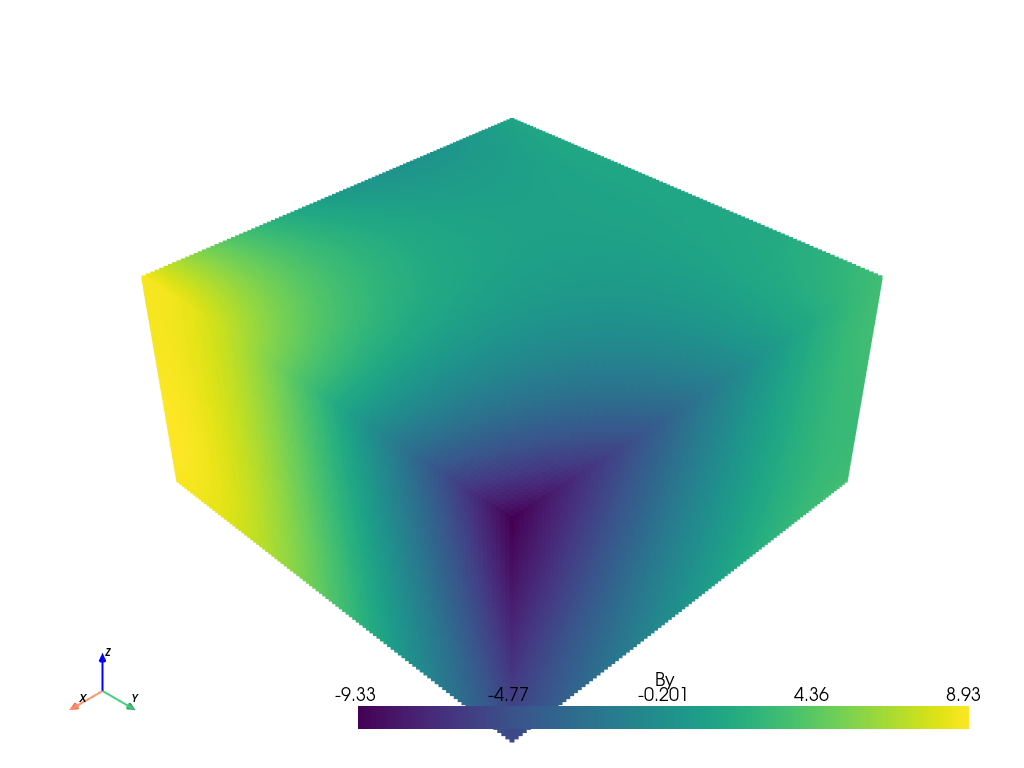

In [ ]:
x= np.linspace(-1,1,101)
y=np.linspace(-1,1,101)
s=np.linspace(0,1,101)
#B=expansion.create_fieldmap(xarr=x,yarr=y,sarr=s, filename=None)
#B.plot()

In [9]:
from sympy.vector import CoordSys3D, curl

Ax, Ay, As = expansion.get_A()

R = CoordSys3D("R")

A = (
    Ax.subs({expansion.x: R.x, expansion.y: R.y, expansion.s: R.z}) * R.i
    + Ay.subs({expansion.x: R.x, expansion.y: R.y, expansion.s: R.z}) * R.j
    + As.subs({expansion.x: R.x, expansion.y: R.y, expansion.s: R.z}) * R.k
)

B_recovered = curl(A)
print("Recovered B field from curl(A):", B_recovered)
# Extract components from B_recovered and substitute back to original variables
Bx_recovered = B_recovered.dot(R.i).subs({R.x: expansion.x, R.y: expansion.y, R.z: expansion.s})
By_recovered = B_recovered.dot(R.j).subs({R.x: expansion.x, R.y: expansion.y, R.z: expansion.s})
Bs_recovered = B_recovered.dot(R.k).subs({R.x: expansion.x, R.y: expansion.y, R.z: expansion.s})
print("Recovered Bx:", Bx_recovered)

Recovered B field from curl(A): (R.x**3 + 5*R.x**2/2 + 2*R.x*R.z + 4*R.y**3*(-(2*R.z**2 - 1)*exp(-R.z**2)/12 - 1/6) + 3*R.y**2*(-R.x - 5/6) + 2*R.y*(R.x**2 + 3*R.x/2 + exp(-R.z**2)/2))*R.i + (2*R.x**3/3 + 3*R.x**2/2 - R.x*R.y**4*R.z**2*(3 - 2*R.z**2)*exp(-R.z**2)/3 - 2*R.x*R.y**4*R.z**2*exp(-R.z**2)/3 + R.x*R.y**4*(3 - 2*R.z**2)*exp(-R.z**2)/6 - 2*R.x*R.y**2*R.z**2*exp(-R.z**2) + R.x*R.y**2*exp(-R.z**2) + R.x*exp(-R.z**2) + R.y**3 - R.y**2*(2*R.x + 3/2) - R.y*(3*R.x**2 + 5*R.x + 2*R.z) + 1)*R.j + (R.x**2 - 2*R.x*R.y**3*R.z*(3 - 2*R.z**2)*exp(-R.z**2)/3 - 2*R.x*R.y*R.z*exp(-R.z**2) - R.y**2)*R.k
Recovered Bx: 2*s*x + x**3 + 5*x**2/2 + 4*y**3*(-(2*s**2 - 1)*exp(-s**2)/12 - 1/6) + 3*y**2*(-x - 5/6) + 2*y*(x**2 + 3*x/2 + exp(-s**2)/2)


Now we can go back to the multipole components using 

$a_{n}(s) = \left. \partial^{n-1}_x B_x(x,y,s) \right|_{x=y=0}$

and

$ b_{n}(s) = \left. \partial^{n-1}_x B_y(x,y,s) \right|_{x=y=0} $

In [10]:
max_order = 4
a_reccoeffs = []
b_reccoeffs = []

for n in range(1, max_order + 1):
  
    a_n = Bx_recovered.diff(expansion.x, n-1).subs({expansion.x: 0, expansion.y: 0})
    a_reccoeffs.append(a_n)#recovered a_n coefficients
    
    b_n = By_recovered.diff(expansion.x, n-1).subs({expansion.x: 0, expansion.y: 0})
    b_reccoeffs.append(b_n)#recovered b_n coefficients

print("\nMultipole coefficients:")
print("a_reccoeffs:", a_reccoeffs)
print("b_reccoeffs:", b_reccoeffs)



Multipole coefficients:
a_reccoeffs: [0, 2*s, 5, 6]
b_reccoeffs: [1, exp(-s**2), 3, 4]


In [11]:
#print again the original coefficients for comparison
print("Original coefficients:")
print("a_coeffs:", a_coeffs)
print("b_coeffs:", b_coeffs)

Original coefficients:
a_coeffs: [0, '2*s', 5, 6]
b_coeffs: [1, 'exp(-s**2)', 3, 4]
